1. LOAD ALL FILES

In [4]:
import pandas as pd
import os

base_path = "data/excel"

all_dfs = []
processed_files = []
skipped_files = []
error_files = []

print("=== START LOADING ===\n")

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(".xlsx"):
            file_path = os.path.join(root, file)

            try:
                df_temp = pd.read_excel(file_path)
                df_temp.columns = df_temp.columns.str.strip().str.lower()

                required_cols = ['frame', 'keypoint_id', 'x', 'y']
                if not all(col in df_temp.columns for col in required_cols):
                    print(f"[SKIP] {file_path} | missing columns: {df_temp.columns.tolist()}")
                    skipped_files.append(file_path)
                    continue

                label = os.path.basename(root)
                video = file.replace(".xlsx", "")

                df_temp['kode_video'] = video
                df_temp['label'] = label
                df_temp['source_path'] = file_path

                all_dfs.append(df_temp)
                processed_files.append(file_path)

                print(f"[OK]   {file_path} | rows: {len(df_temp)}")

            except Exception as e:
                print(f"[ERR]  {file_path} | {e}")
                error_files.append(file_path)

print("\n=== SUMMARY ===")
print(f"Processed (OK) : {len(processed_files)}")
print(f"Skipped        : {len(skipped_files)}")
print(f"Errors         : {len(error_files)}")

# Tampilkan daftar file
print("\n=== FILE LIST ===")
print("\n-- OK --")
for f in processed_files:
    print(f)

print("\n-- SKIPPED --")
for f in skipped_files:
    print(f)

print("\n-- ERROR --")
for f in error_files:
    print(f)

# safety check
if len(all_dfs) == 0:
    raise ValueError("No valid data loaded.")

# concat
df = pd.concat(all_dfs, ignore_index=True)

print("\nFinal shape:", df.shape)

=== START LOADING ===

[OK]   data/excel\AKU CIUM BAU BADAN DIA\P01.xlsx | rows: 15910
[OK]   data/excel\AKU CIUM BAU BADAN DIA\P02.xlsx | rows: 16770
[OK]   data/excel\AKU CIUM BAU BADAN DIA\P03.xlsx | rows: 12900
[OK]   data/excel\AKU CIUM BAU BADAN DIA\P04.xlsx | rows: 20640
[OK]   data/excel\AKU CIUM BAU BADAN DIA\P05.xlsx | rows: 11352
[OK]   data/excel\AKU LIHAT ADA ULAR MASUK KELAS\P01.xlsx | rows: 17630
[OK]   data/excel\AKU LIHAT ADA ULAR MASUK KELAS\P02.xlsx | rows: 23220
[OK]   data/excel\AKU LIHAT ADA ULAR MASUK KELAS\P03.xlsx | rows: 18920
[OK]   data/excel\AKU LIHAT ADA ULAR MASUK KELAS\P04.xlsx | rows: 24510
[OK]   data/excel\AKU LIHAT ADA ULAR MASUK KELAS\P05.xlsx | rows: 14620
[OK]   data/excel\AKU NILAI JELEK\P01.xlsx | rows: 9030
[OK]   data/excel\AKU NILAI JELEK\P02.xlsx | rows: 14620
[OK]   data/excel\AKU NILAI JELEK\P03.xlsx | rows: 9030
[OK]   data/excel\AKU NILAI JELEK\P04.xlsx | rows: 14620
[OK]   data/excel\AKU NILAI JELEK\P05.xlsx | rows: 15480
[OK]   data/ex

2. MOTION COMPUTATION

In [5]:
# =========================
# CELL 2: MOTION COMPUTATION
# =========================

print("=== START MOTION COMPUTATION ===")

# 1. SORT (WAJIB)
df = df.sort_values(by=['kode_video', 'keypoint_id', 'frame'])
df = df.reset_index(drop=True)

print("Sorted dataframe")

# 2. HITUNG PREVIOUS FRAME
df['prev_x'] = df.groupby(['kode_video', 'keypoint_id'])['x'].shift(1)
df['prev_y'] = df.groupby(['kode_video', 'keypoint_id'])['y'].shift(1)

print("Computed previous frame (shift)")

# 3. VALIDASI LANDMARK
df['valid_current'] = ~((df['x'] == 0) & (df['y'] == 0))
df['valid_prev'] = ~((df['prev_x'] == 0) & (df['prev_y'] == 0))

df['valid_motion'] = df['valid_current'] & df['valid_prev']

print("Computed valid motion mask")

# 4. HITUNG DISPLACEMENT
df['dx'] = df['x'] - df['prev_x']
df['dy'] = df['y'] - df['prev_y']

df['displacement'] = np.sqrt(df['dx']**2 + df['dy']**2)

# buang yang tidak valid
df.loc[~df['valid_motion'], 'displacement'] = np.nan

print("Computed displacement")

# 5. MAPPING BODY PART
def map_body_part(kp):
    if kp <= 20:
        return 'GL'
    elif kp <= 41:
        return 'GR'
    elif kp <= 60:
        return 'GM'
    else:
        return 'GP'

df['body_part'] = df['keypoint_id'].apply(map_body_part)

print("Mapped body parts")

# 6. QUICK CHECK
print("\n=== QUICK STATS ===")
print("Total rows:", len(df))
print("Valid motion count:", df['displacement'].notna().sum())
print("Invalid motion:", df['displacement'].isna().sum())

print("\nSample:")
print(df[['kode_video', 'frame', 'keypoint_id', 'x', 'y', 'displacement', 'body_part']].head())

=== START MOTION COMPUTATION ===
Sorted dataframe
Computed previous frame (shift)
Computed valid motion mask
Computed displacement
Mapped body parts

=== QUICK STATS ===
Total rows: 2795258
Valid motion count: 2016831
Invalid motion: 778427

Sample:
  kode_video  frame  keypoint_id    x    y  displacement body_part
0        P01      0            0  0.0  0.0           NaN        GL
1        P01      0            0  0.0  0.0           NaN        GL
2        P01      0            0  0.0  0.0           NaN        GL
3        P01      0            0  0.0  0.0           NaN        GL
4        P01      0            0  0.0  0.0           NaN        GL


In [6]:
print(df['displacement'].describe())

count    2.016831e+06
mean     1.366523e-01
std      1.655088e-01
min      5.830678e-06
25%      3.274943e-02
50%      7.437114e-02
75%      1.736608e-01
max      1.564356e+00
Name: displacement, dtype: float64


3. AGGREGATION & SUMMARY

=== START AGGREGATION ===
Valid rows: 2016831

=== PER VIDEO SAMPLE ===
  kode_video body_part      mean           sum   count
0        P01        GL  0.216160   5883.008292   27216
1        P01        GM  0.038875   4242.654343  109136
2        P01        GP  0.132918  19093.639378  143650
3        P01        GR  0.180835  14183.767844   78435
4        P02        GL  0.231926  18522.310078   79863

=== PER LABEL ===
                              label body_part      mean          sum  count
0            AKU CIUM BAU BADAN DIA        GL  0.301968   849.737487   2814
1            AKU CIUM BAU BADAN DIA        GM  0.063278  1077.247155  17024
2            AKU CIUM BAU BADAN DIA        GP  0.128592  2883.685804  22425
3            AKU CIUM BAU BADAN DIA        GR  0.228159  2941.879511  12894
4    AKU LIHAT ADA ULAR MASUK KELAS        GL  0.216165  1280.126386   5922
..                              ...       ...       ...          ...    ...
115             ULANG TAHUN SELAMAT        GR  

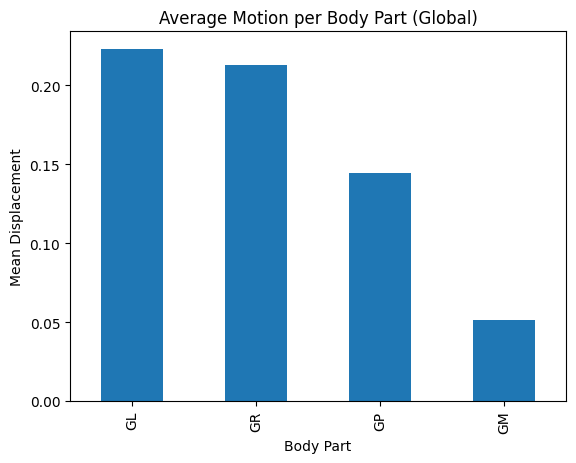

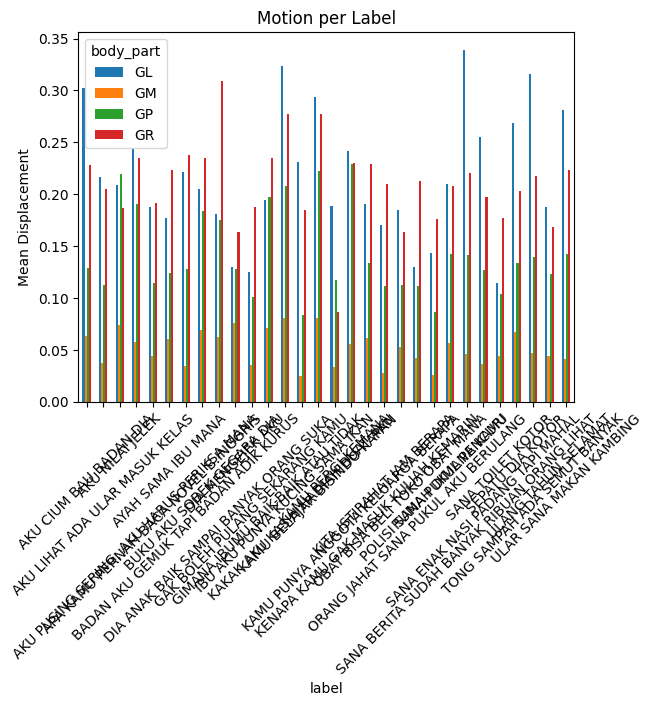

In [7]:
# =========================
# CELL 3: AGGREGATION
# =========================

print("=== START AGGREGATION ===")

# pastikan hanya pakai data valid
df_valid = df[df['displacement'].notna()].copy()

print("Valid rows:", len(df_valid))


# =========================
# 1. PER VIDEO
# =========================
per_video = (
    df_valid
    .groupby(['kode_video', 'body_part'])['displacement']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

print("\n=== PER VIDEO SAMPLE ===")
print(per_video.head())


# =========================
# 2. PER LABEL (KELAS)
# =========================
per_label = (
    df_valid
    .groupby(['label', 'body_part'])['displacement']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

print("\n=== PER LABEL ===")
print(per_label)


# =========================
# 3. GLOBAL SUMMARY
# =========================
global_summary = (
    df_valid
    .groupby('body_part')['displacement']
    .agg(['mean', 'sum', 'count'])
    .sort_values(by='mean', ascending=False)
)

print("\n=== GLOBAL SUMMARY ===")
print(global_summary)


# =========================
# 4. MOTION RATIO (KRITIS)
# =========================
total_motion = global_summary['sum'].sum()
global_summary['ratio'] = global_summary['sum'] / total_motion

print("\n=== GLOBAL + RATIO ===")
print(global_summary)


# =========================
# 5. SORT RANKING
# =========================
global_summary['rank'] = global_summary['mean'].rank(ascending=False)

print("\n=== FINAL RANKING ===")
print(global_summary)


# =========================
# 6. VISUALISASI GLOBAL
# =========================
plt.figure()
global_summary['mean'].plot(kind='bar')
plt.title('Average Motion per Body Part (Global)')
plt.ylabel('Mean Displacement')
plt.xlabel('Body Part')
plt.show()


# =========================
# 7. VISUALISASI PER LABEL
# =========================
pivot_label = per_label.pivot(index='label', columns='body_part', values='mean')

pivot_label.plot(kind='bar')
plt.title('Motion per Label')
plt.ylabel('Mean Displacement')
plt.xticks(rotation=45)
plt.show()

In [8]:
print(global_summary)

               mean            sum   count     ratio  rank
body_part                                                 
GL         0.223038   39001.926629  174867  0.141514   1.0
GR         0.213023   87841.448239  412356  0.318723   2.0
GP         0.144144  117109.465593  812450  0.424918   3.0
GM         0.051286   31651.734115  617158  0.114845   4.0


In [13]:
!pip install seaborn

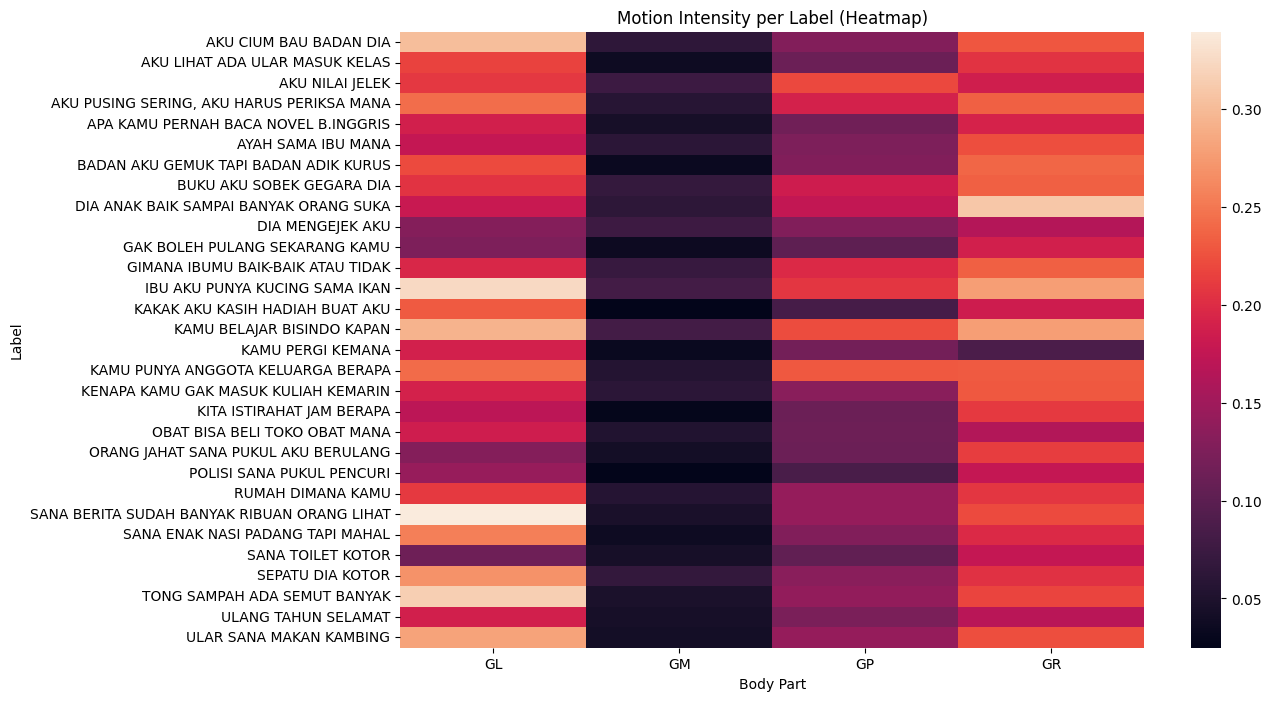

In [14]:
import seaborn as sns

plt.figure(figsize=(12, 8))
pivot_label = per_label.pivot(index='label', columns='body_part', values='mean')

sns.heatmap(pivot_label, annot=False)

plt.title("Motion Intensity per Label (Heatmap)")
plt.ylabel("Label")
plt.xlabel("Body Part")
plt.show()

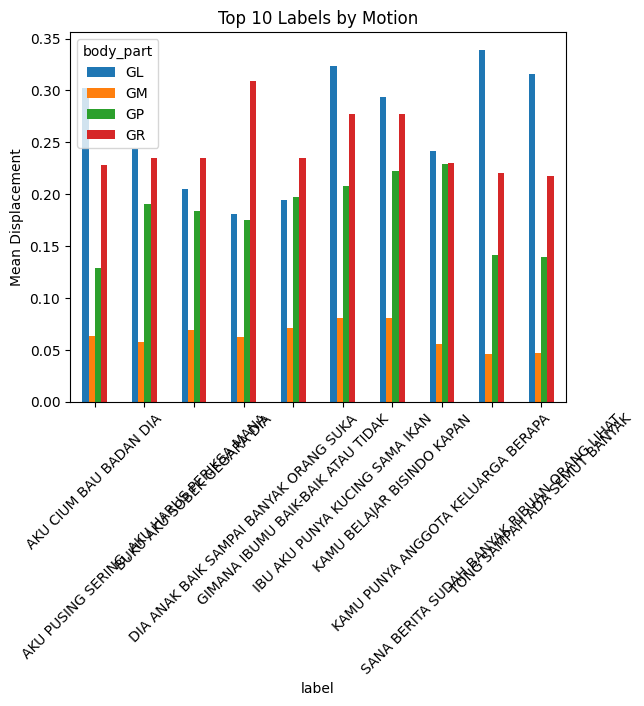

In [15]:
top_labels = (
    per_label.groupby('label')['mean']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

filtered = per_label[per_label['label'].isin(top_labels)]

pivot_top = filtered.pivot(index='label', columns='body_part', values='mean')

pivot_top.plot(kind='bar')
plt.title("Top 10 Labels by Motion")
plt.ylabel("Mean Displacement")
plt.xticks(rotation=45)
plt.show()

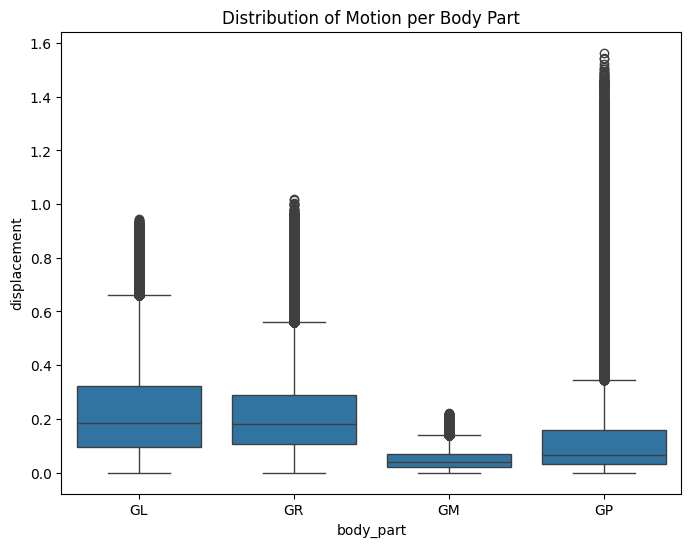

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=df_valid, x='body_part', y='displacement')

plt.title("Distribution of Motion per Body Part")
plt.show()

In [17]:
# global
global_summary.to_csv("global_summary.csv")

# per label
per_label.to_csv("per_label.csv", index=False)

# per video
per_video.to_csv("per_video.csv", index=False)